In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('diabetes.csv')

In [9]:
df.shape

(768, 9)

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
# Check for the Nulls
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
# Check For Duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
def Outliers_percent(df, col):
    first_quantile = df[col].quantile(0.25)
    third_quantile = df[col].quantile(0.75)
    IQR = third_quantile - first_quantile
    Upper_limit = third_quantile + 1.5 * IQR
    Lower_limit = first_quantile - 1.5 * IQR

    outliers = df[(df[col] > Upper_limit) | (df[col] < Lower_limit)]
    outlier_count = outliers.shape[0]

    return (outlier_count / df.shape[0]) * 100

The Outliers in COL :Pregnancies  is 0.5208333333333333


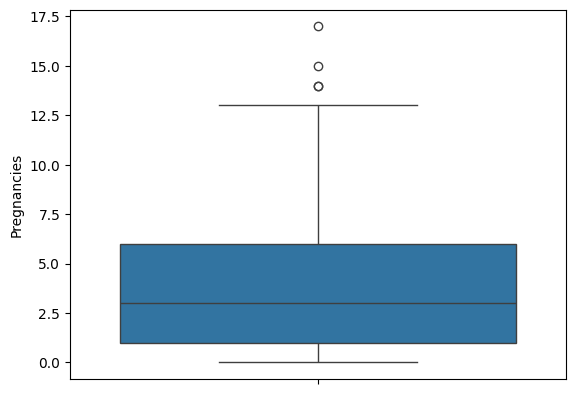

The Outliers in COL :Glucose  is 0.6510416666666667


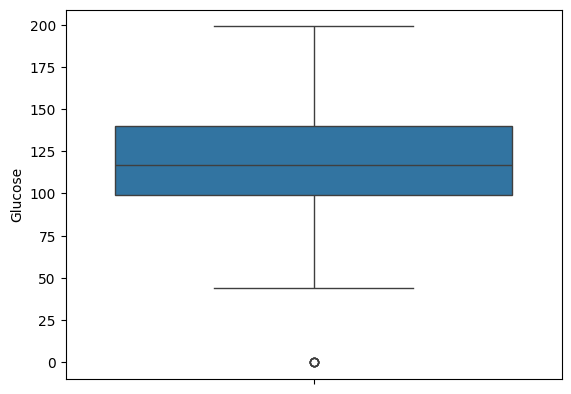

The Outliers in COL :BloodPressure  is 5.859375


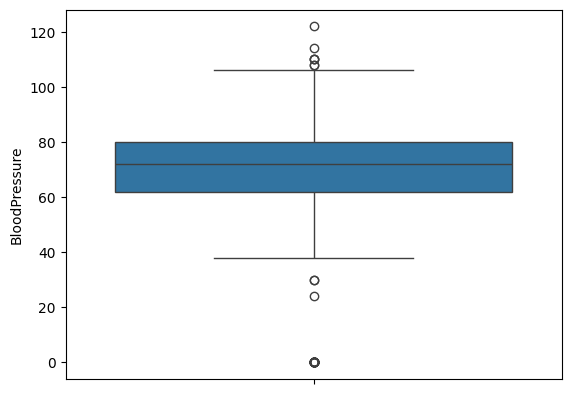

The Outliers in COL :SkinThickness  is 0.13020833333333331


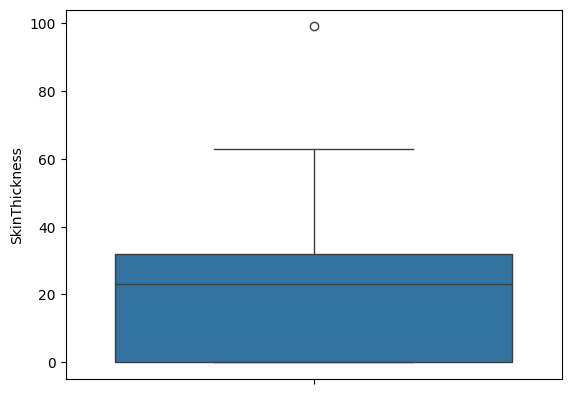

The Outliers in COL :Insulin  is 4.427083333333334


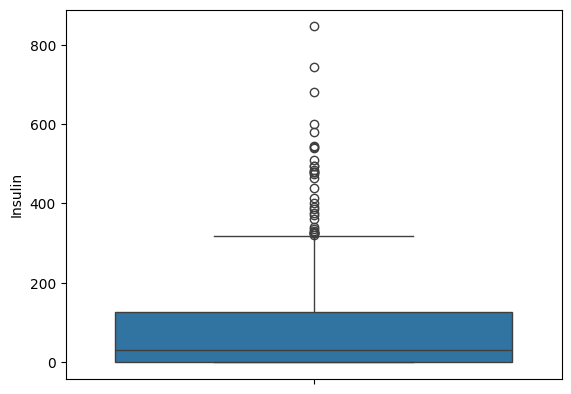

The Outliers in COL :BMI  is 2.473958333333333


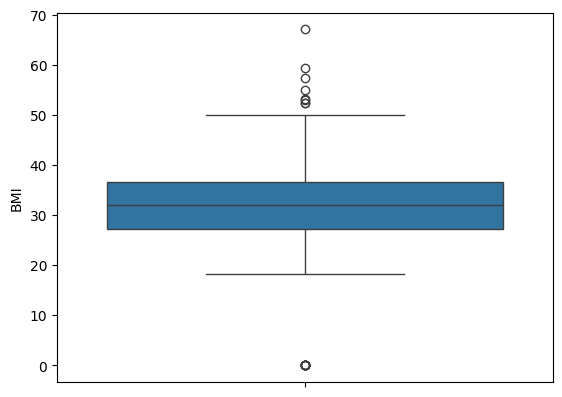

The Outliers in COL :DiabetesPedigreeFunction  is 3.7760416666666665


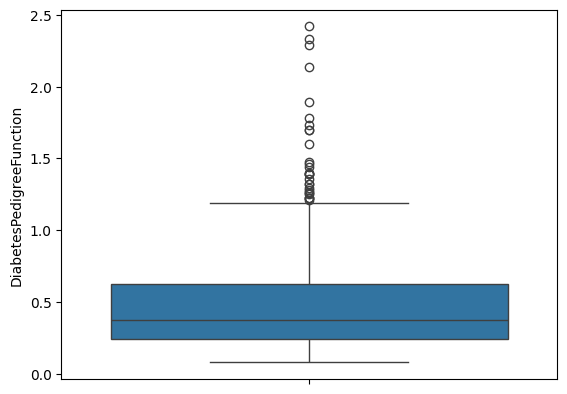

The Outliers in COL :Age  is 1.171875


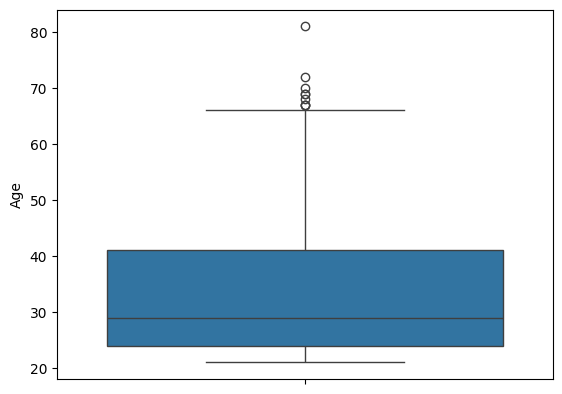

The Outliers in COL :Outcome  is 0.0


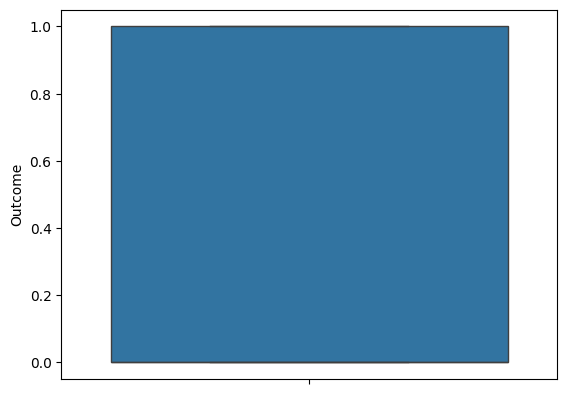

In [8]:
# Check For the Outliers
for i in df.select_dtypes(include = 'number').columns:
  print(f"The Outliers in COL :{i}  is {Outliers_percent(df , i)}")
  sns.boxplot(df[i])
  plt.show()

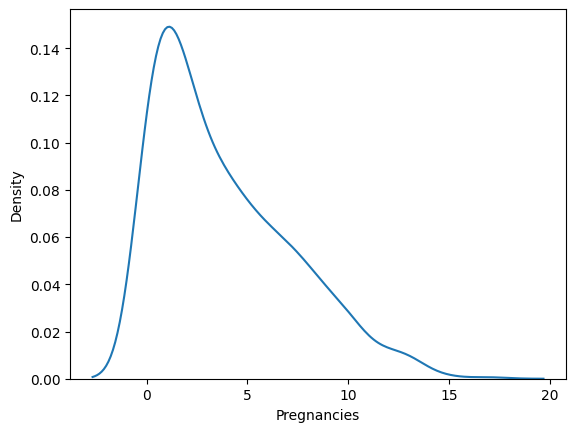

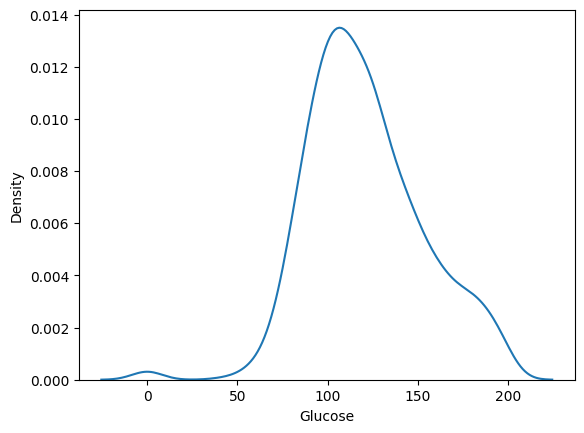

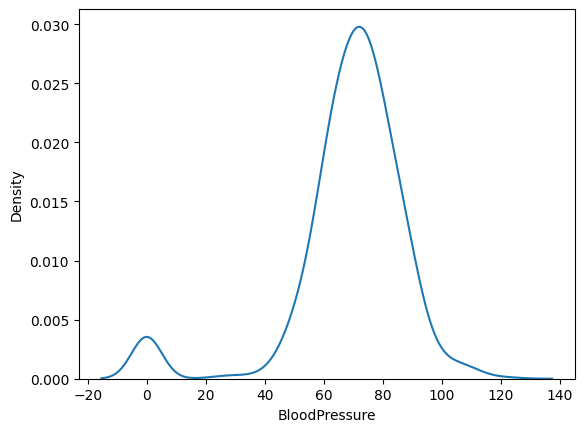

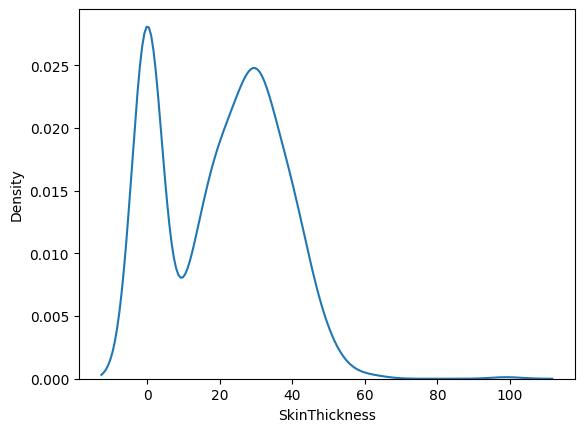

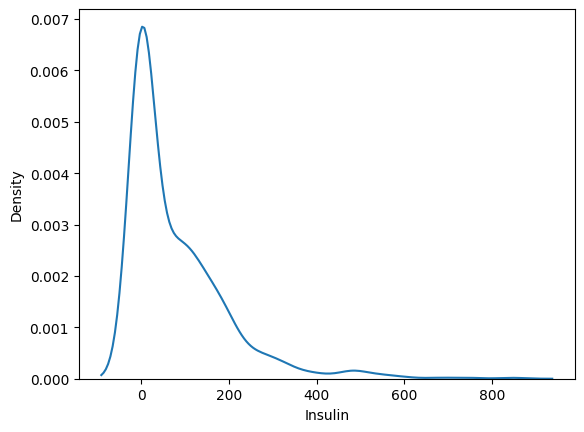

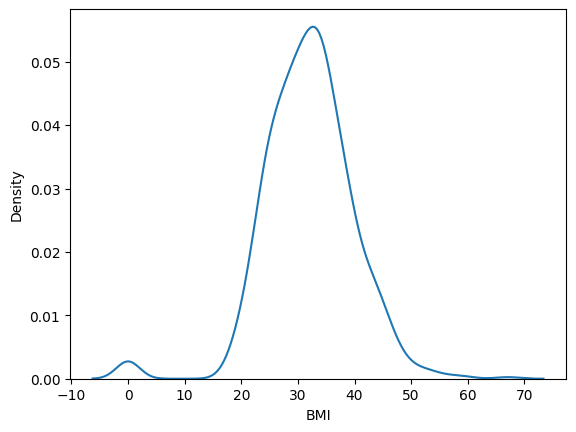

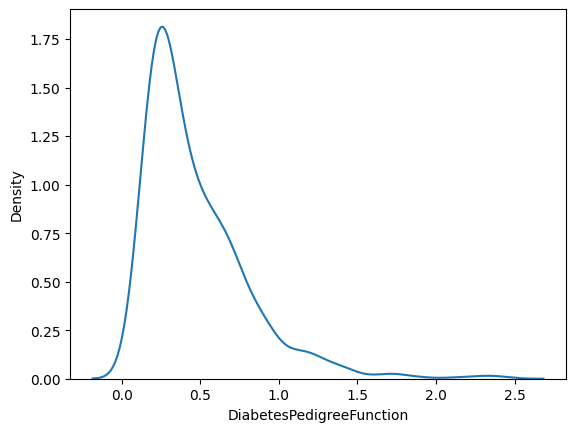

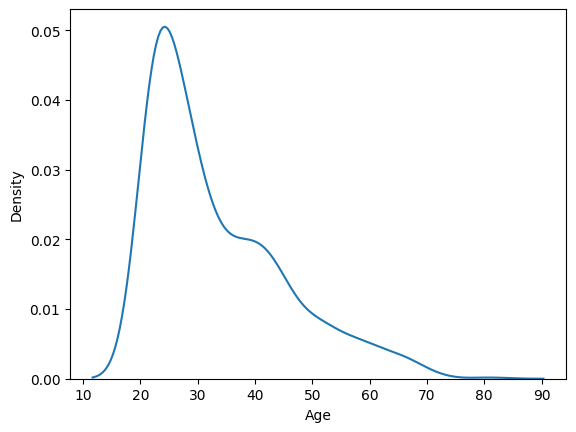

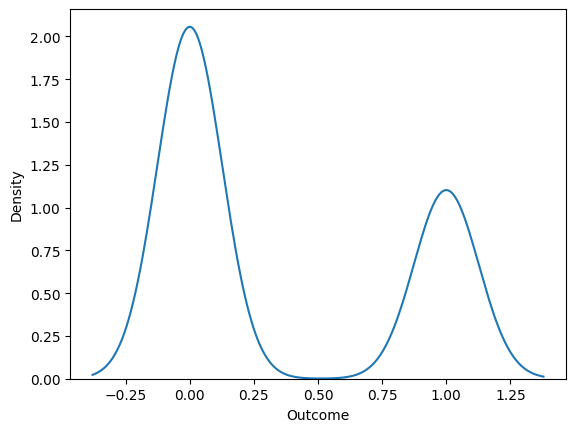

In [12]:
# Check For the Data Distibution
for Col in df.select_dtypes(include = 'number').columns:
  sns.kdeplot(df[Col])
  plt.show()

<Axes: >

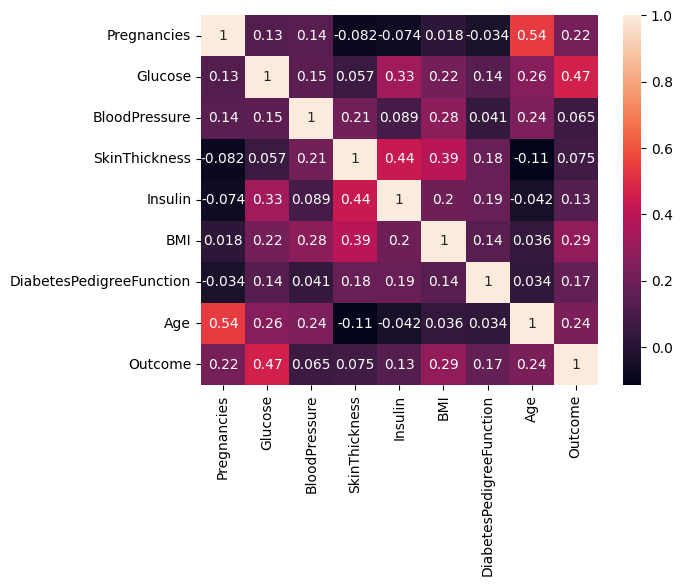

In [13]:
# Check The Colleration
corr = df.corr(numeric_only=True)
sns.heatmap(corr , annot =True)
# The Glucose is the Most Collerant Column to Distinquishe Between Diabetes or Not

In [15]:
# Checking For Data Imbalance
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [37]:
x = df.drop('Outcome',axis = 1)
y = df['Outcome']

In [40]:
# Try to Smote the Data
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x,y = smote.fit_resample(x_train,y_train)

In [38]:
# Standrization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_scales_data = sc.fit_transform(x)

In [39]:
# Splitting the Data
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x_scales_data,y,test_size = 0.2 , random_state = 42,stratify = y)

In [41]:
# Import SVM
from sklearn import svm
Model = svm.SVC(kernel = 'linear')

In [42]:
# Fitting the Data
Model.fit(x,y)

SVC(kernel='linear')

In [46]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [43]:
# Evaluate on the Trained Data
from sklearn.metrics import accuracy_score , recall_score
predict = Model.predict(x_train)
print(f"The Accuracy Score is {accuracy_score(y_train,predict)}")
print(f"The Recall Score is {recall_score(y_train,predict)}")

The Accuracy Score is 0.7703583061889251
The Recall Score is 0.7009345794392523


In [44]:
predict = Model.predict(x_test)
print(f"The Accuracy Score is {accuracy_score(y_test,predict)}")
print(f"The Recall Score is {recall_score(y_test,predict)}")

The Accuracy Score is 0.7207792207792207
The Recall Score is 0.6296296296296297


In [49]:
input_data = (1,	147,	94,	41,	0,	49.3,	0.358,	27)
input_data_as_numpy_Arr = np.asarray(input_data)
input_Data_reshaped = input_data_as_numpy_Arr.reshape(1,-1)
input_datta = sc.transform(input_Data_reshaped)
prediction = Model.predict(input_datta)
if prediction[0] == 0:
  print("The Person is Not Diabetic")
else:
  print("The Person is Diabetic")

The Person is Diabetic


In [52]:
import pickle
pickle.dump(Model, open('Diabetic_Model_Predict.pkl','wb'))
pickle.dump(sc , open('Standard_Scaler.pkl','wb'))

In [53]:
# Getting out the Requirements
!pip freeze > requirement.txt